In [1]:
# Imports

import os
import random
import re
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import tensorflow as tf

from skimage.color import rgb2gray
from skimage.transform import resize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_class_weight


SEED = 12345

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

VIEWS = ["axial", "coronal", "sagittal"]

> **Note:** This setup script only needs to be **run once**. It loads and downloads all the data into your local folder, which takes approximately **45 minutes** to complete.

```python
from pathlib import Path
import re
import pandas as pd
import redivis

dataset = redivis.organization("AIMI").dataset("mrnet_knee_mri_s:4a2c")
out_dir = Path("StanfordMRNet")

for split in ["train", "valid"]:
    labels = pd.read_csv(f"{split}_acl_labels.csv", header=None)

    case_ids = {
        int(re.search(r"\d+", str(case)).group())
        for case in labels[0]
    }

    split_dir = out_dir / split
    split_dir.mkdir(parents=True, exist_ok=True)

    table = dataset.table(split)
    files = table.to_pandas_dataframe()

    for _, row in files.iterrows():
        file_name = str(row["file_name"])
        case_id = int(re.search(r"\d+", Path(file_name).stem).group())

        if case_id in case_ids:
            file_path = split_dir / file_name

            if not file_path.exists():
                file_path.parent.mkdir(parents=True, exist_ok=True)
                table.file(row["file_id"]).download(str(file_path))

In [2]:
#Mapping: CSV labels -> case IDs -> train/test case sets

def first_int(value):
    """Pull the first run of digits out of a value (case IDs and labels are read as strings)."""
    return int(re.search(r"\d+", str(value)).group())

def load_label_map(csv_path):
    """Headerless CSV: column 0 = case ID, column 1 = ACL label (0 = Normal, 1 = Torn)."""
    df = pd.read_csv(csv_path, header=None)
    return {first_int(case): first_int(label) for case, label in zip(df[0], df[1])}

def paths_for_view(view):
    return sorted(Path(f"StanfordMRNet/train/{view}").glob("*.npy"))

# Only the Stanford "train" split is used anywhere in this notebook. The "valid" folder/labels are
# not touched - our own 80/20 train/test split is instead carved out of the train pool below.
label_map = load_label_map("train_acl_labels.csv")
label_names = {0: "Normal", 1: "Torn"}

# Every view's images must exactly match the labeled cases: no unlabeled images, no missing
# images, and axial/coronal/sagittal must all cover the identical set of case IDs.
view_ids = {view: {first_int(p.stem) for p in paths_for_view(view)} for view in VIEWS}
assert all(ids == set(label_map) for ids in view_ids.values()), \
    "Each view's .npy files must correspond to exactly the cases labeled in train_acl_labels.csv."

# Outer 80/20 split, computed once over the full train pool.
all_ids_sorted = sorted(label_map)
train_case_ids, test_case_ids = train_test_split(
    all_ids_sorted, test_size=0.2,
    stratify=[label_map[c] for c in all_ids_sorted], random_state=SEED,
)
train_case_ids, test_case_ids = set(train_case_ids), set(test_case_ids)

# Inner split, carved from the 80% train pool only, used solely for hyperparameter tuning below.
train_ids_sorted = sorted(train_case_ids)
inner_train_ids, inner_holdout_ids = train_test_split(
    train_ids_sorted, test_size=0.2,
    stratify=[label_map[c] for c in train_ids_sorted], random_state=SEED,
)
inner_train_ids, inner_holdout_ids = set(inner_train_ids), set(inner_holdout_ids)

def class_counts(case_ids):
    labels = [label_map[c] for c in case_ids]
    return len(case_ids), labels.count(0), labels.count(1)

for name, ids in [
    ("Train pool", train_case_ids),
    ("Test set (held out)", test_case_ids),
    ("Inner train (tuning)", inner_train_ids),
    ("Inner holdout (tuning)", inner_holdout_ids),
]:
    n, n0, n1 = class_counts(ids)
    print(f"{name}: {n} cases (Normal={n0}, Torn={n1})")


Train pool: 904 cases (Normal=738, Torn=166)
Test set (held out): 226 cases (Normal=184, Torn=42)
Inner train (tuning): 723 cases (Normal=590, Torn=133)
Inner holdout (tuning): 181 cases (Normal=148, Torn=33)


In [3]:
#Preprocessing: center slice -> resize -> grayscale -> normalize to [0,1]

IMG_SIZE = (64, 64)

def load_center_slice(path):
    volume = np.load(path, allow_pickle=True)
    center = volume[volume.shape[0] // 2] if volume.ndim == 3 else volume
    if center.ndim == 3:
        center = rgb2gray(center)
    return resize(center, IMG_SIZE, anti_aliasing=True).astype(np.float32)

def build_arrays(view, case_ids):
    """Case IDs -> (images, labels) for one view."""
    paths = {first_int(p.stem): p for p in paths_for_view(view)}
    ids = sorted(case_ids)
    images = np.stack([load_center_slice(paths[c]) for c in ids])
    labels = np.array([label_map[c] for c in ids])
    return np.clip(images, 0.0, 1.0), labels


In [4]:
# Models

def build_svm(C, kernel="rbf", gamma="scale"):
    return make_pipeline(
        StandardScaler(),
        SVC(C=C, kernel=kernel, gamma=gamma, random_state=SEED, class_weight="balanced")
    )


def build_logreg(C, solver="lbfgs"):
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(
            C=C,
            solver=solver,
            max_iter=2000,
            random_state=SEED,
            class_weight="balanced"
        )
    )


def build_cnn(input_shape, learning_rate=1e-4):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
        tf.keras.layers.MaxPool2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [5]:
# Data loading per view

view_data = {}

for view in VIEWS:
    X_train, y_train = build_arrays(view, train_case_ids)
    X_test, y_test = build_arrays(view, test_case_ids)
    X_inner_train, y_inner_train = build_arrays(view, inner_train_ids)
    X_inner_holdout, y_inner_holdout = build_arrays(view, inner_holdout_ids)

    view_data[view] = {
        "train": (X_train, y_train),
        "test": (X_test, y_test),
        "inner_train": (X_inner_train, y_inner_train),
        "inner_holdout": (X_inner_holdout, y_inner_holdout),
    }

    print(f"{view}: train={len(X_train)}, test={len(X_test)}")

axial: train=904, test=226


coronal: train=904, test=226


sagittal: train=904, test=226


In [6]:
# Model training (CNN): fit each view on the inner-train split, validated on the inner holdout

cnn_learning_rates = {
    "axial": 0.0005,
    "coronal": 0.0001,
    "sagittal": 0.0001,
}

for view in VIEWS:
    X_train, y_train = view_data[view]["inner_train"]
    X_val, y_val = view_data[view]["inner_holdout"]
    X_train = X_train[..., np.newaxis]
    X_val = X_val[..., np.newaxis]

    print(f"\n[{view}]")
    model = build_cnn(X_train.shape[1:], learning_rate=cnn_learning_rates[view])
    model.fit(
        X_train, y_train,
        epochs=8, batch_size=16,
        validation_data=(X_val, y_val),
        verbose=2,
    )


[axial]
Epoch 1/8


46/46 - 1s - 21ms/step - accuracy: 0.8064 - loss: 0.4928 - val_accuracy: 0.8177 - val_loss: 0.5155


Epoch 2/8


46/46 - 0s - 10ms/step - accuracy: 0.8160 - loss: 0.4726 - val_accuracy: 0.8177 - val_loss: 0.4756


Epoch 3/8


...

46/46 - 0s - 10ms/step - accuracy: 0.8160 - loss: 0.4329 - val_accuracy: 0.8177 - val_loss: 0.4447


Epoch 7/8


46/46 - 0s - 10ms/step - accuracy: 0.8160 - loss: 0.4167 - val_accuracy: 0.8177 - val_loss: 0.4385


Epoch 8/8


46/46 - 0s - 10ms/step - accuracy: 0.8174 - loss: 0.4012 - val_accuracy: 0.8177 - val_loss: 0.4360


In [7]:
# Final 10-fold CV (no test evaluation)

N_SPLITS = 10
Path("optimized_models").mkdir(exist_ok=True)

svm_hparams = {
    "axial": {"C": 0.1, "kernel": "rbf", "gamma": "scale"},
    "coronal": {"C": 0.1, "kernel": "rbf", "gamma": "scale"},
    "sagittal": {"C": 1, "kernel": "rbf", "gamma": "scale"},
}

logreg_hparams = {
    "axial": {"C": 0.1, "solver": "lbfgs"},
    "coronal": {"C": 0.1, "solver": "lbfgs"},
    "sagittal": {"C": 0.1, "solver": "lbfgs"},
}

y = np.array([label_map[c] for c in train_case_ids])

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

folds = list(cv.split(np.zeros(len(y)), y))
results = []
cnn_histories = {}

for view in VIEWS:

    X_train, y_train = view_data[view]["train"]

    X_flat = X_train.reshape(len(X_train), -1)

    # SVM + Logistic Regression
    for name, build_fn, params in [
        ("svm", build_svm, svm_hparams[view]),
        ("logreg", build_logreg, logreg_hparams[view])
    ]:

        oof_pred = np.zeros(len(y_train), dtype=int)
        fold_accs = []
        fold_f1s = []

        for train_idx, val_idx in folds:

            model = build_fn(**params)
            model.fit(X_flat[train_idx], y_train[train_idx])

            pred = model.predict(X_flat[val_idx])
            oof_pred[val_idx] = pred

            fold_accs.append(
                accuracy_score(y_train[val_idx], pred)
            )

            fold_f1s.append(
                precision_recall_fscore_support(
                    y_train[val_idx],
                    pred,
                    average="macro"
                )[2]
            )

        cv_acc = accuracy_score(y_train, oof_pred)
        cv_prec, cv_rec, cv_f1, _ = precision_recall_fscore_support(
            y_train,
            oof_pred,
            average="macro"
        )

        final_model = build_fn(**params)
        final_model.fit(X_flat, y_train)

        joblib.dump(
            final_model,
            f"optimized_models/{name}_{view}.joblib"
        )


        results.append({
            "model": name,
            "view": view,
            "cv_accuracy": cv_acc,
            "cv_precision": cv_prec,
            "cv_recall": cv_rec,
            "cv_f1": cv_f1,
            "cv_fold_accuracies": fold_accs,
            "cv_fold_f1s": fold_f1s
        })

    # CNN
    X_train_cnn = X_train[..., np.newaxis]

    lr = cnn_learning_rates[view]

    oof_pred = np.zeros(len(y_train), dtype=int)
    fold_accs = []
    fold_f1s = []

    for train_idx, val_idx in folds:

        model = build_cnn(
            X_train_cnn.shape[1:],
            learning_rate=lr
        )

        fold_cw = compute_class_weight(
            class_weight="balanced",
            classes=np.array([0, 1]),
            y=y_train[train_idx]
        )
        fold_class_weight = {0: fold_cw[0], 1: fold_cw[1]}

        model.fit(
            X_train_cnn[train_idx],
            y_train[train_idx],
            epochs=8,
            batch_size=16,
            verbose=0,
            class_weight=fold_class_weight
        )

        pred = (
            model.predict(
                X_train_cnn[val_idx],
                verbose=0
            ).ravel() >= 0.5
        ).astype(int)

        oof_pred[val_idx] = pred

        fold_accs.append(
            accuracy_score(y_train[val_idx], pred)
        )

        fold_f1s.append(
            precision_recall_fscore_support(
                y_train[val_idx],
                pred,
                average="macro"
            )[2]
        )

    cv_acc = accuracy_score(y_train, oof_pred)
    cv_prec, cv_rec, cv_f1, _ = precision_recall_fscore_support(
        y_train,
        oof_pred,
        average="macro"
    )

    final_model = build_cnn(
        X_train_cnn.shape[1:],
        learning_rate=lr
    )

    final_cw = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),
        y=y_train
    )
    final_class_weight = {0: final_cw[0], 1: final_cw[1]}

    class TrainF1(tf.keras.callbacks.Callback):
        # macro F1 on the training pool at the end of each epoch
        def __init__(self):
            super().__init__()
            self.f1s = []

        def on_epoch_end(self, epoch, logs=None):
            p = (self.model.predict(X_train_cnn, verbose=0).ravel() >= 0.5).astype(int)
            self.f1s.append(
                precision_recall_fscore_support(y_train, p, average="macro")[2]
            )

    train_f1 = TrainF1()

    history = final_model.fit(
        X_train_cnn,
        y_train,
        epochs=8,
        batch_size=16,
        verbose=0,
        class_weight=final_class_weight,
        callbacks=[train_f1]
    )

    cnn_histories[view] = {
        "loss": history.history["loss"],
        "f1": train_f1.f1s
    }

    final_model.save(
        f"optimized_models/cnn_{view}.keras"
    )


    results.append({
        "model": "cnn",
        "view": view,
        "cv_accuracy": cv_acc,
        "cv_precision": cv_prec,
        "cv_recall": cv_rec,
        "cv_f1": cv_f1,
        "cv_fold_accuracies": fold_accs,
        "cv_fold_f1s": fold_f1s
    })

results_df = pd.DataFrame(results)

display(
    results_df[
        [
            "model",
            "view",
            "cv_accuracy",
            "cv_precision",
            "cv_recall",
            "cv_f1"
        ]
    ]
)

/Users/neel/Documents/GitHub/ACLInjuryDetection/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


/Users/neel/Documents/GitHub/ACLInjuryDetection/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,model,view,cv_accuracy,cv_precision,cv_recall,cv_f1
0,svm,axial,0.536504,0.570160,0.615739,0.501673
1,logreg,axial,0.758850,0.591984,0.588500,0.590130
2,cnn,axial,0.682522,0.628769,0.707505,0.619050
3,svm,coronal,0.480088,0.513842,0.522823,0.441368
4,logreg,coronal,0.722345,0.549216,0.552135,0.550449
5,cnn,coronal,0.550885,0.532795,0.554511,0.490154
6,svm,sagittal,0.811947,0.669133,0.618686,0.634370
7,logreg,sagittal,0.785398,0.642113,0.642113,0.642113
8,cnn,sagittal,0.724558,0.639435,0.709905,0.645455


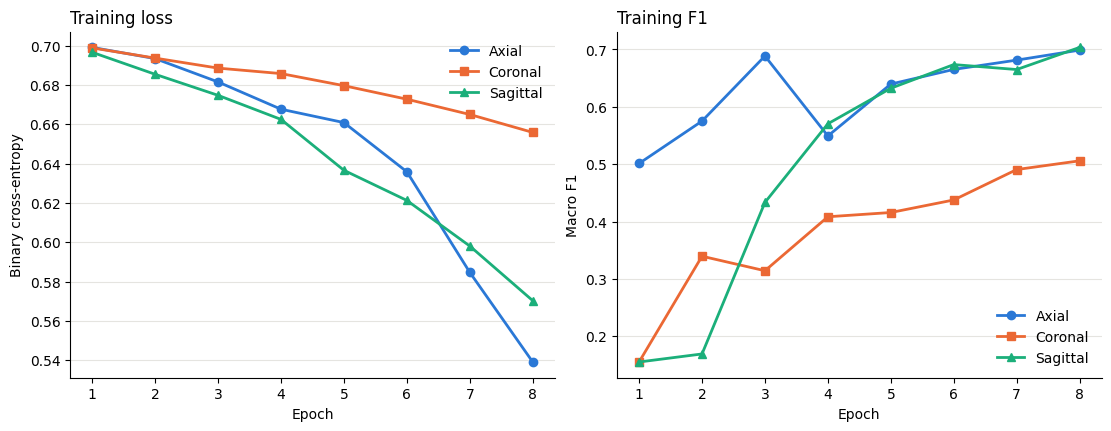

In [8]:
# CNN training loss + accuracy per epoch (final fit on the 904-case train pool, before CV)
import matplotlib.pyplot as plt

colors = {"axial": "#2a78d6", "coronal": "#eb6834", "sagittal": "#1baf7a"}
markers = {"axial": "o", "coronal": "s", "sagittal": "^"}

fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

for view in VIEWS:
    h = cnn_histories[view]
    epochs = range(1, len(h["loss"]) + 1)
    for ax, key in [(ax_loss, "loss"), (ax_acc, "f1")]:
        ax.plot(epochs, h[key], color=colors[view], marker=markers[view],
                markersize=6, linewidth=2, label=view.capitalize())

for ax, title, ylabel in [(ax_loss, "Training loss", "Binary cross-entropy"),
                          (ax_acc, "Training F1", "Macro F1")]:
    ax.set_title(title, loc="left", fontsize=12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(1, len(cnn_histories[VIEWS[0]]["loss"]) + 1))
    ax.grid(axis="y", color="#e5e4e0", linewidth=0.8)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.legend(frameon=False)

plt.savefig("cnn_training_curves.png", dpi=150)
plt.show()


In [9]:
#Final comparison table + findings (10-fold CV metrics only; the test set is never used)

summary_table = results_df[[
    "model", "view", "cv_accuracy", "cv_f1", "cv_precision", "cv_recall"
]].rename(columns={
    "model": "Model", "view": "View", "cv_accuracy": "CV Accuracy", "cv_f1": "CV F1",
    "cv_precision": "CV Precision", "cv_recall": "CV Recall",
})
print(summary_table.to_string(index=False))

best_cv_row = results_df.loc[results_df["cv_f1"].idxmax()]
best_model_by_cv = results_df.groupby("model")["cv_accuracy"].mean().idxmax()
best_view_by_cv = results_df.groupby("view")["cv_accuracy"].mean().idxmax()
least_stable = results_df.assign(fold_std=results_df["cv_fold_accuracies"].apply(np.std)) \
    .sort_values("fold_std", ascending=False).iloc[0]

print(f"\nBest combo by CV F1 (selection uses CV only): {best_cv_row['model']} / {best_cv_row['view']} "
      f"(cv_accuracy={best_cv_row['cv_accuracy']:.3f}, cv_f1={best_cv_row['cv_f1']:.3f}).")
print(f"Best model by mean CV accuracy across views: {best_model_by_cv}")
print(f"Best view by mean CV accuracy across models: {best_view_by_cv}")
print(f"Least stable across CV folds: {least_stable['model']} / {least_stable['view']} "
      f"(fold accuracy std={least_stable['fold_std']:.3f})")


 Model     View  CV Accuracy    CV F1  CV Precision  CV Recall
   svm    axial     0.536504 0.501673      0.570160   0.615739
logreg    axial     0.758850 0.590130      0.591984   0.588500
   cnn    axial     0.682522 0.619050      0.628769   0.707505
   svm  coronal     0.480088 0.441368      0.513842   0.522823
logreg  coronal     0.722345 0.550449      0.549216   0.552135
   cnn  coronal     0.550885 0.490154      0.532795   0.554511
   svm sagittal     0.811947 0.634370      0.669133   0.618686
logreg sagittal     0.785398 0.642113      0.642113   0.642113
   cnn sagittal     0.724558 0.645455      0.639435   0.709905

Best combo by CV F1 (selection uses CV only): cnn / sagittal (cv_accuracy=0.725, cv_f1=0.645).
Best model by mean CV accuracy across views: logreg
Best view by mean CV accuracy across models: sagittal
Least stable across CV folds: svm / coronal (fold accuracy std=0.208)
